## House Pricing Detection

## STEP 1 — Import Libraries

In [159]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [160]:
path = "house_prices.csv"
pd.read_csv(path)

,HouseID,Location,Bedrooms,Bathrooms,SquareFeet,Price
0,1,Chicago,1,2,1928,266294
1,2,Chicago,2,1,1093,83082
2,3,New York,3,1,2100,431828
3,4,Chicago,4,2,2456,85311
4,5,Los Angeles,4,2,1524,267251
...,...,...,...,...,...,...
995,996,New York,3,2,2528,253692
996,997,Los Angeles,1,2,563,113057
997,998,New York,1,1,793,387508
998,999,Los Angeles,4,2,625,85333


## STEP 2 — Load & Understand the Data

In [161]:
df = pd.read_csv(path)

In [162]:
print(df.head())

   HouseID     Location  Bedrooms  Bathrooms  SquareFeet   Price
0        1      Chicago         1          2        1928  266294
1        2      Chicago         2          1        1093   83082
2        3     New York         3          1        2100  431828
3        4      Chicago         4          2        2456   85311
4        5  Los Angeles         4          2        1524  267251


In [163]:
df.dtypes

HouseID        int64
Location      object
Bedrooms       int64
Bathrooms      int64
SquareFeet     int64
Price          int64
dtype: object

In [164]:
df.describe()

,HouseID,Bedrooms,Bathrooms,SquareFeet,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2.495000,1.525000,1743.524000,281536.431000
std,288.819436,1.105983,0.499624,725.252486,132390.173003
min,1.000000,1.000000,1.000000,501.000000,50267.000000
25%,250.750000,2.000000,1.000000,1102.500000,165854.750000
50%,500.500000,2.000000,2.000000,1727.000000,290911.500000
75%,750.250000,3.000000,2.000000,2370.250000,397076.500000
max,1000.000000,4.000000,2.000000,2999.000000,499890.000000


In [165]:
print(df.isnull().sum())

HouseID       0
Location      0
Bedrooms      0
Bathrooms     0
SquareFeet    0
Price         0
dtype: int64


## STEP 3 — Exploratory Data Analysis (EDA)

In [166]:
# we will do in the last 

## STEP 4 — Data Preprocessing

In [167]:
# Drop HouseID — it's just a serial number, not useful for prediction
df = df.drop(columns=['HouseID'])

# One-Hot Encode the 'Location' column (convert city names to numbers)
df = pd.get_dummies(df, columns=['Location'], drop_first=True)


In [168]:
print(df.head())

   Bedrooms  Bathrooms  SquareFeet   Price  Location_Houston  \
0         1          2        1928  266294             False   
1         2          1        1093   83082             False   
2         3          1        2100  431828             False   
3         4          2        2456   85311             False   
4         4          2        1524  267251             False   

   Location_Los Angeles  Location_New York  
0                 False              False  
1                 False              False  
2                 False               True  
3                 False              False  
4                  True              False  


In [169]:
print(df.columns.tolist())

['Bedrooms', 'Bathrooms', 'SquareFeet', 'Price', 'Location_Houston', 'Location_Los Angeles', 'Location_New York']


## STEP 5 — Split Features & Target, then Train-Test Split

In [170]:
from sklearn.model_selection import train_test_split

# X = input features,  y = what we want to predict
X = df.drop(columns=['Price'])
Y = df['Price']

# 80% for training, 20% for testing
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
) 

print("Training rows :", X_train.shape[0])
print("Testing rows  :", X_test.shape[0])

Training rows : 800
Testing rows  : 200


## STEP 6 — Build & Train the Models

In [171]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

model ={
    "Liner Regression" : LinearRegression(),
    "Decision Tree" : DecisionTreeRegressor(random_state=42),
    "Random Forest"     : RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in model.items():
    model.fit(X_train, Y_train)
    print(f"{name} trained sucessfully")

Liner Regression trained sucessfully
Decision Tree trained sucessfully
Random Forest trained sucessfully


## STEP 7 — Evaluate the Models

In [173]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

for name, model in models.items():
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f"\n {name}")
    print(f"   MAE  : ${mae:,.0f}")
    print(f"   RMSE : ${rmse:,.0f}")
    print(f"   R²   : {r2:.4f}")


 Linear Regression
   MAE  : $115,045
   RMSE : $133,987
   R²   : -0.0042

 Decision Tree
   MAE  : $165,933
   RMSE : $197,102
   R²   : -1.1732

 Random Forest
   MAE  : $125,189
   RMSE : $149,250
   R²   : -0.2460


## STEP 8 — Hyperparameter Tuning (Improve the Best Model)

In [174]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10, 20],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV R² Score:", round(grid.best_score_, 4))

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Best CV R² Score: -0.0389


## STEP 9 — Visualize Predictions

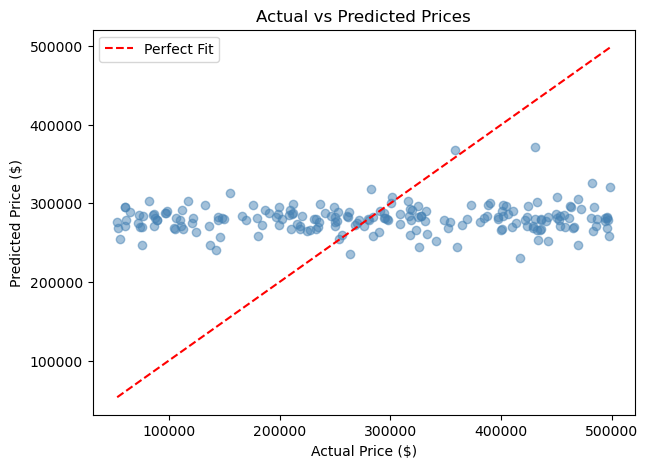

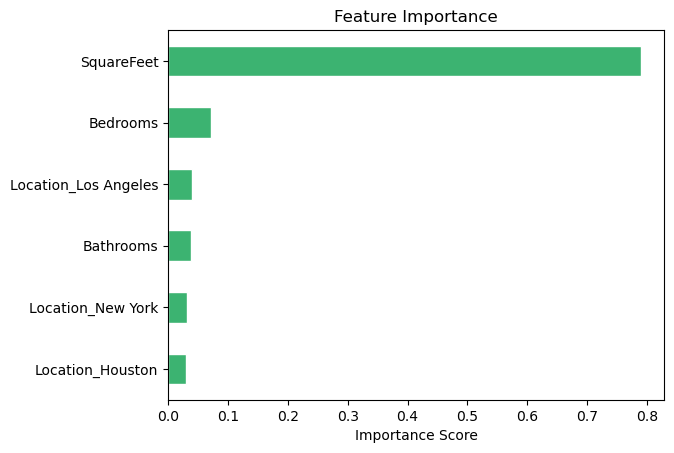

In [175]:
best_model = grid.best_estimator_
y_pred_final = best_model.predict(X_test)


# Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_final, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.show()


# Feature Importance
feat_imp = pd.Series(best_model.feature_importances_,
                     index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', color='mediumseagreen', edgecolor='white')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

## STEP 10 — Predict Price for a New House

In [176]:
import pandas as pd

new_house = pd.DataFrame([{
    'Bedrooms'             : 3,
    'Bathrooms'            : 2,
    'SquareFeet'           : 1800,
    'Location_Houston'     : 0,
    'Location_Los Angeles' : 0,
    'Location_New York'    : 1,   # ← New York
}])

predicted_price = best_model.predict(new_house)[0]
print(f" Predicted Price: ${predicted_price:,.0f}")

💰 Predicted Price: $271,592
